In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import functools
from pathlib import Path

from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from sklearn.manifold import TSNE
import tqdm.auto as tqdm
import distinctipy

from dti import data
from dti.utils import scaffold_split
from dti.constants import SMILES, ASSAY, ACT

sns.set_context("talk")

In [2]:
FP = "fingerprint"

In [3]:
data_path = Path("..") / "data" / "raw"

In [4]:
df = data.load_kinodata(data_path / "activities-chembl33_v0.5.csv")

# Remove assays with less than 100 compounds
df = df[df[ASSAY].map(df[ASSAY].value_counts()) > 100]

# Scaffold split the remaining set
df_train, df_test = scaffold_split(df, seed=0)
df_train["train"] = True
df_test["train"] = False
df = pd.concat([df_train, df_test])

scaffold:   0%|          | 0/45444 [00:00<?, ?it/s]

In [5]:
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)

In [6]:
@functools.cache
def get_fp(smi):
    try:
        return mfpgen.GetFingerprintAsNumPy(Chem.MolFromSmiles(smi))
    except:
        return None

In [7]:
df.loc[:, FP] = [get_fp(smi) for smi in tqdm.tqdm(df[SMILES].values)]
df = df[~df[FP].isna()]

  0%|          | 0/45444 [00:00<?, ?it/s]

In [8]:
N = 49

In [9]:
np.random.seed(0)
assays = np.random.choice(df[ASSAY].unique(), N)
d = df[df[ASSAY].isin(assays)]
fp_matrix = np.vstack(d[FP].values)

In [10]:
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
tsne_results = tsne.fit_transform(fp_matrix)

In [11]:
d["tsne-2d-one"] = tsne_results[:, 0]
d["tsne-2d-two"] = tsne_results[:, 1]

/tmp/ipykernel_1971095/1288223382.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d["tsne-2d-one"] = tsne_results[:, 0]
/tmp/ipykernel_1971095/1288223382.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  d["tsne-2d-two"] = tsne_results[:, 1]


In [12]:
assays
cmap = dict(zip(assays, distinctipy.get_colors(len(assays))))
colors = [cmap[aid] for aid in d[ASSAY]]

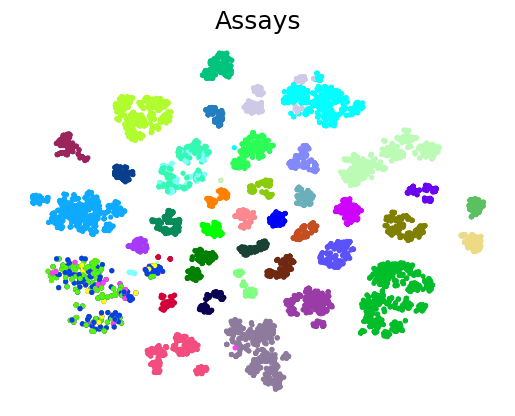

In [18]:
plt.scatter(d["tsne-2d-one"], d["tsne-2d-two"], c=colors, s=5)
plt.xticks([])
plt.yticks([])
plt.title("Assays")
sns.despine(left=True, bottom=True)

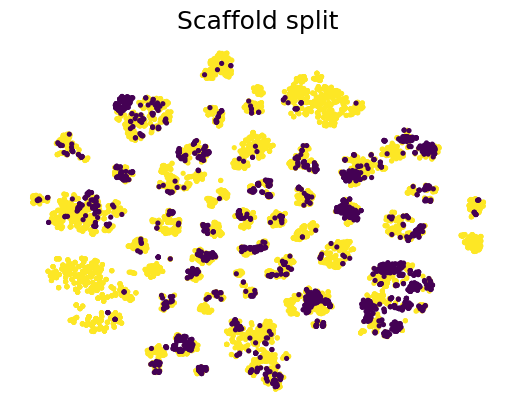

In [19]:
plt.scatter(d["tsne-2d-one"], d["tsne-2d-two"], c=d["train"], s=5)
plt.xticks([])
plt.yticks([])
plt.title("Scaffold split")
sns.despine(left=True, bottom=True)

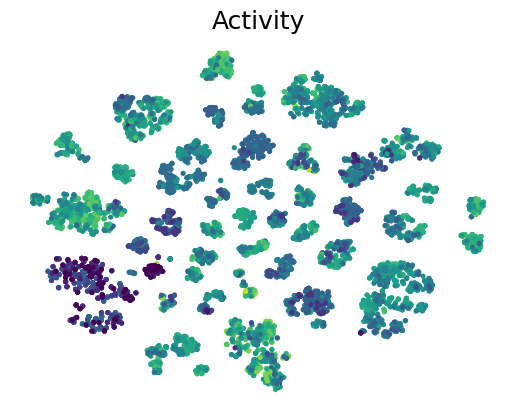

In [24]:
plt.scatter(d["tsne-2d-one"], d["tsne-2d-two"], c=d[ACT], cmap="viridis", s=5)
plt.xticks([])
plt.yticks([])
plt.title("Activity")
sns.despine(left=True, bottom=True)